# Linear Regression — Testing All 7 Assumptions
California Housing dataset · sklearn train/test split · statsmodels + scipy diagnostics.

## Setup

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

raw = fetch_california_housing(as_frame=True)
df  = raw.frame

X = df[raw.feature_names]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
y_pred    = model.predict(X_test)
residuals = y_test.values - y_pred

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 16,512  |  Test: 4,128


---
## Assumption 1: Linearity

**What it means:** The relationship between each feature and the target must be linear.

**How to read it:** Look for a roughly linear cloud of points. Strong curves or bends suggest
the relationship is non-linear and the feature may need a transformation (log, polynomial, etc.).

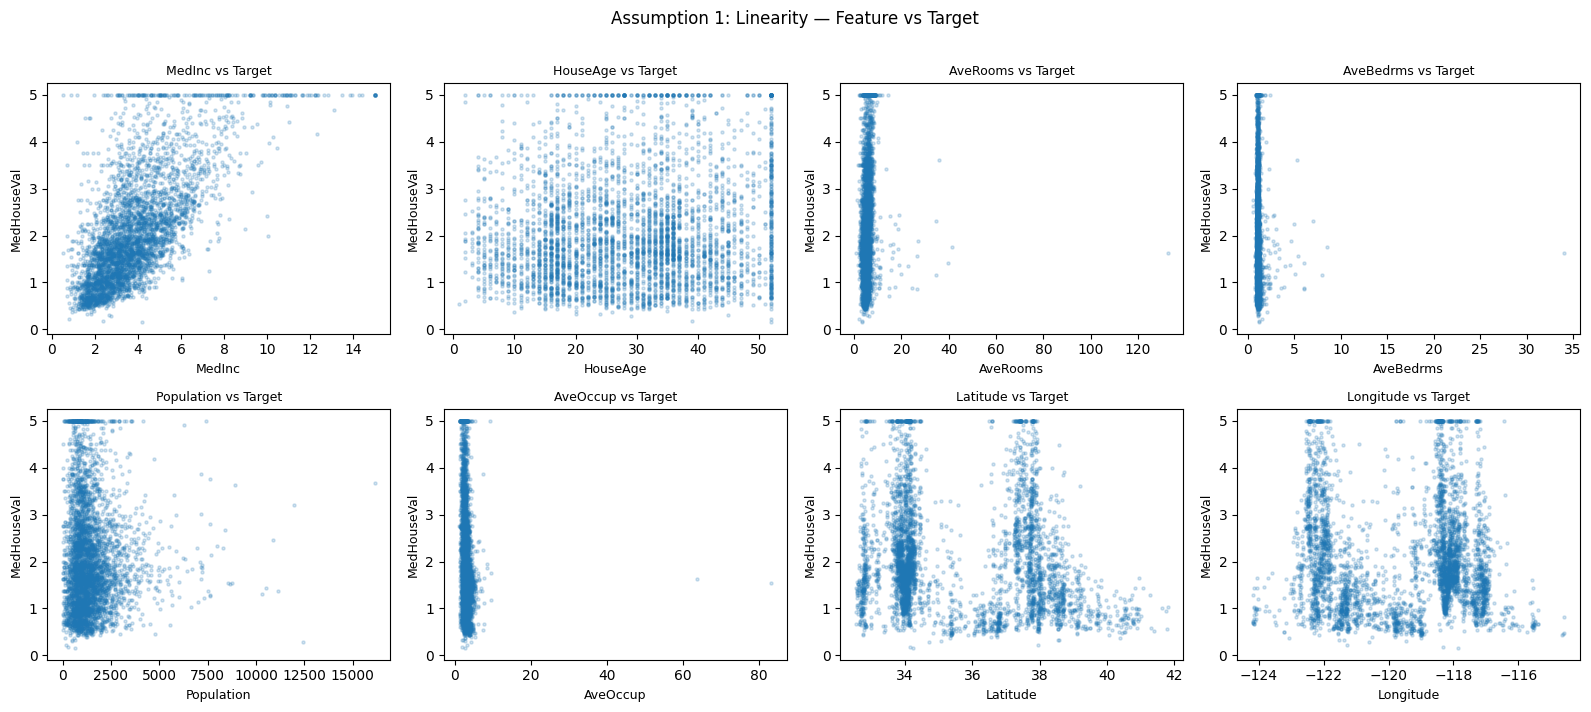

In [10]:
features = raw.feature_names
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].scatter(X_test[feat], y_test, alpha=0.2, s=5)
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel("MedHouseVal", fontsize=9)
    axes[i].set_title(f"{feat} vs Target", fontsize=9)

if len(features) < len(axes):
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle("Assumption 1: Linearity — Feature vs Target", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Assumption 2: Independence of Errors (Durbin-Watson)

**What it means:** Residuals must not be correlated with each other (no autocorrelation).

**How to read it:** Durbin-Watson statistic ranges from 0 to 4.
- ~2 → no autocorrelation ✓
- < 1.5 → positive autocorrelation
- > 2.5 → negative autocorrelation

In [11]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw:.4f}")
if 1.5 <= dw <= 2.5:
    print("Interpretation: No significant autocorrelation detected ✓")
elif dw < 1.5:
    print("Interpretation: Positive autocorrelation detected ✗")
else:
    print("Interpretation: Negative autocorrelation detected ✗")

Durbin-Watson statistic: 2.0407
Interpretation: No significant autocorrelation detected ✓


---
## Assumption 3: Homoscedasticity

**What it means:** Residuals should have constant variance at every level of the fitted values.

**How to read it:** The residuals vs fitted plot should show a horizontal band with no
funnel shape. A widening or narrowing spread indicates heteroscedasticity — variance is
changing with the predicted value.

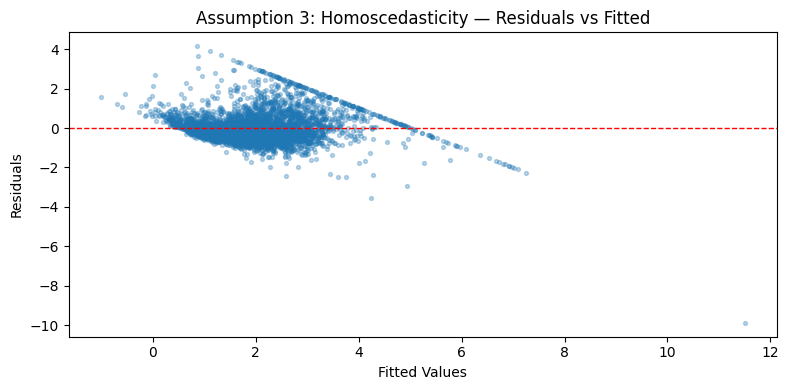

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(y_pred, residuals, alpha=0.3, s=8)
ax.axhline(0, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.set_title("Assumption 3: Homoscedasticity — Residuals vs Fitted")
plt.tight_layout()
plt.show()

---
## Assumption 4: Normality of Residuals

**What it means:** Residuals should be approximately normally distributed.

**How to read it:**
- **Histogram:** Should look bell-shaped.
- **Q-Q plot:** Points should fall along the diagonal reference line.
  Deviations at the tails indicate skewness or heavy tails.

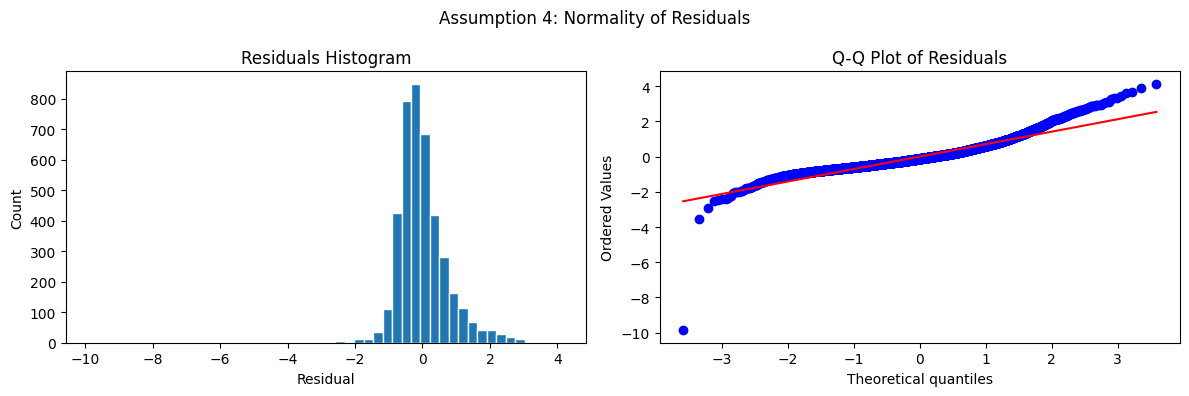

Shapiro-Wilk p-value (n=500 sample): 0.0000
Interpretation: Non-normal ✗


In [13]:
from scipy import stats

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(residuals, bins=50, edgecolor="white")
ax1.set_xlabel("Residual")
ax1.set_ylabel("Count")
ax1.set_title("Residuals Histogram")

stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot of Residuals")

plt.suptitle("Assumption 4: Normality of Residuals", fontsize=12)
plt.tight_layout()
plt.show()

_, p_value = stats.shapiro(residuals[:500])  # Shapiro-Wilk on subset (n≤5000)
print(f"Shapiro-Wilk p-value (n=500 sample): {p_value:.4f}")
print("Interpretation:", "Normal ✓" if p_value > 0.05 else "Non-normal ✗")

---
## Assumption 5: No Multicollinearity (VIF)

**What it means:** Features should not be highly correlated with each other.
Multicollinearity inflates coefficient variance and makes them unreliable.

**How to read it:** Variance Inflation Factor (VIF):
- VIF = 1 → no correlation
- VIF 1–5 → moderate (acceptable)
- VIF > 10 → severe multicollinearity ✗

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_train_arr = X_train.values
vif_data = pd.DataFrame({
    "Feature": raw.feature_names,
    "VIF":     [variance_inflation_factor(X_train_arr, i) for i in range(X_train_arr.shape[1])]
})
vif_data["Flag"] = vif_data["VIF"].apply(lambda v: "✗ High" if v > 10 else ("⚠ Moderate" if v > 5 else "✓"))
vif_data.sort_values("VIF", ascending=False)

,Feature,VIF,Flag
7,Longitude,641.224254,✗ High
6,Latitude,560.583263,✗ High
3,AveBedrms,48.332634,✗ High
2,AveRooms,46.792373,✗ High
0,MedInc,11.831609,✗ High
1,HouseAge,7.155405,⚠ Moderate
4,Population,2.915730,✓
5,AveOccup,1.080609,✓


---
## Assumption 6: No Influential Outliers (Cook's Distance)

**What it means:** Individual data points should not disproportionately influence
the fitted model. Influential points can distort coefficients.

**How to read it:** Cook's Distance > 4/n is a common threshold for concern.
Points above this line in the plot are potentially influential outliers.

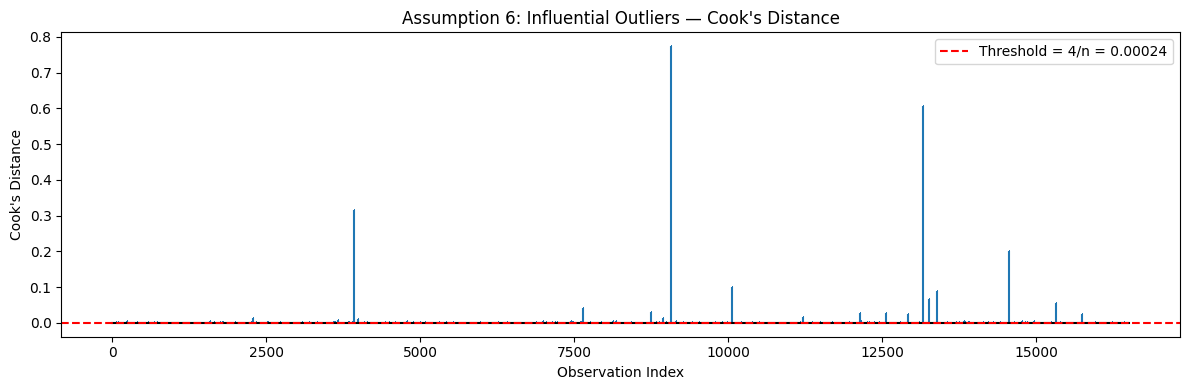

Observations above threshold: 762 (4.6%)


In [15]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
ols_model  = sm.OLS(y_train, X_train_sm).fit()
influence  = ols_model.get_influence()
cooks_d, _ = influence.cooks_distance

threshold = 4 / len(X_train)

fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=",", linefmt="C0-", basefmt="k-")
ax.axhline(threshold, color="red", linestyle="--", label=f"Threshold = 4/n = {threshold:.5f}")
ax.set_xlabel("Observation Index")
ax.set_ylabel("Cook's Distance")
ax.set_title("Assumption 6: Influential Outliers — Cook's Distance")
ax.legend()
plt.tight_layout()
plt.show()

n_influential = (cooks_d > threshold).sum()
print(f"Observations above threshold: {n_influential} ({100*n_influential/len(cooks_d):.1f}%)")

---
## Assumption 7: No Autocorrelation (ACF Plot)

**What it means:** Residuals should not exhibit patterns over their sequence —
each residual should be independent of the others.

**How to read it:** Bars outside the shaded 95% confidence band indicate
statistically significant autocorrelation at that lag. For cross-sectional
data like housing, this should largely hold; for time series it is critical.

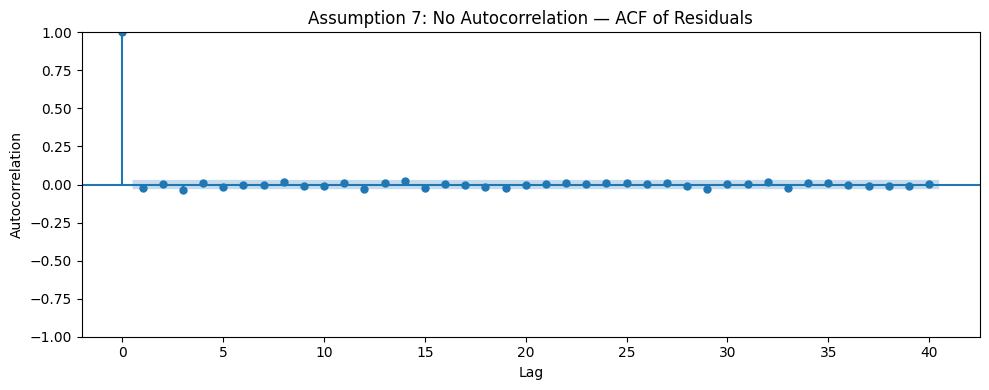

In [16]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(residuals, lags=40, alpha=0.05, ax=ax)
ax.set_title("Assumption 7: No Autocorrelation — ACF of Residuals")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.show()